# Non-centered parameterization of hierarchical effects

When a hierarchical model has a group-specific term with a random scale hyperprior, such as `b ~ Normal(0, sigma)` with a prior over `sigma`, Bambi can rewrite the term as `z ~ Normal(0, 1)` together with `b = z * sigma`. This is the **non-centered parameterization**, and it often improves the geometry of the posterior, making sampling more efficient.

In this notebook we are going to see how to control non-centered parameterization in Bambi. We can set it once for the whole model, on individual priors, or independently for each parameter of the response distribution. We will use the **sleepstudy** dataset throughout.

In [1]:
import bambi as bmb

## Load data

The **sleepstudy** dataset is derived from the study described in [Belenky et al. (2003)](https://pubmed.ncbi.nlm.nih.gov/12603781/) and popularized in the [lme4](https://CRAN.R-project.org/package=lme4) R package. It contains the average reaction time per day for 18 subjects whose sleep was restricted to 3 hours per night. We can load it with `bmb.load_data()`.

In [2]:
data = bmb.load_data("sleepstudy")
data.head()

,Reaction,Days,Subject
0,249.5600,0,308
1,258.7047,1,308
2,250.8006,2,308
3,321.4398,3,308
4,356.8519,4,308


## Model-wide setting

`bmb.Model(..., noncentered=True)` is the default. It turns on the offset trick for every group-specific term that has a random `sigma` hyperprior. After `model.build()`, the offset variables show up in the PyMC graph.

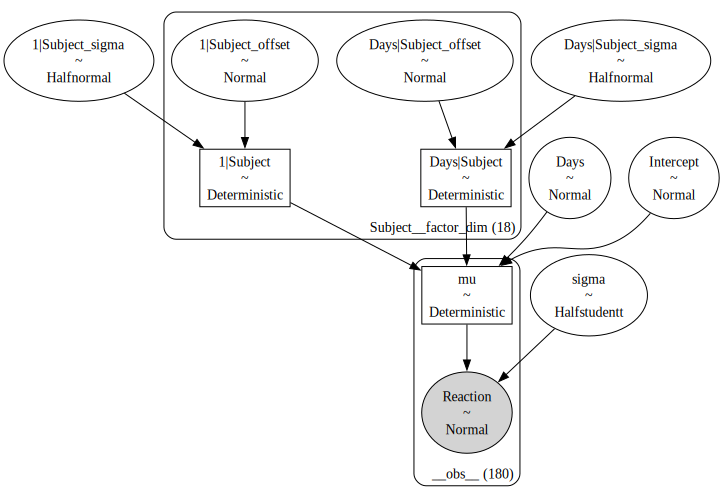

In [3]:
m_nc = bmb.Model("Reaction ~ Days + (Days | Subject)", data, noncentered=True)
m_nc.build()
m_nc.graph()

Setting `noncentered=False` removes them.

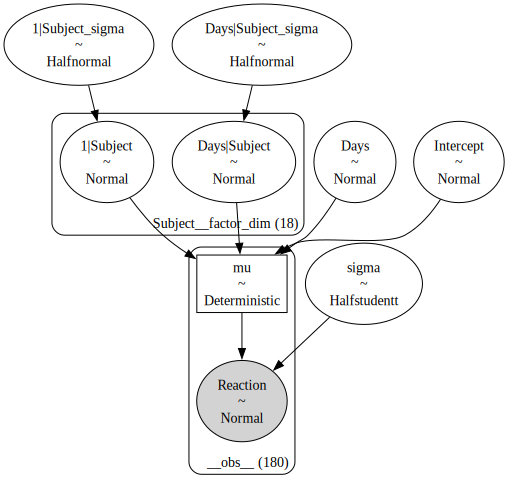

In [4]:
m_c = bmb.Model("Reaction ~ Days + (Days | Subject)", data, noncentered=False)
m_c.build()
m_c.graph()

## Per-prior setting

`bmb.Prior` accepts a `noncentered` keyword. The default `None` inherits the model-level value; `True` or `False` overrides it for that specific prior.

In the next model we keep the intercept-by-subject term non-centered and ask the slope-by-subject term to use the centered parameterization. We set the model-wide `noncentered=False` to show that the per-prior `noncentered=True` on the intercept term still wins.

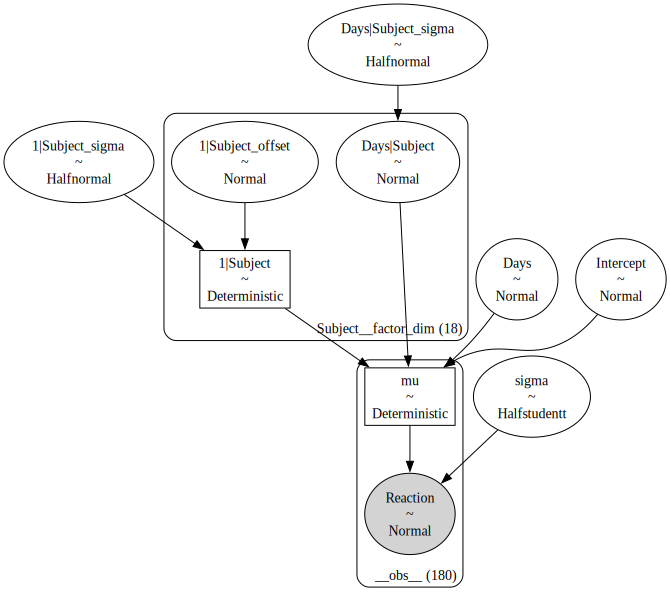

In [5]:
priors = {
    "1|Subject": bmb.Prior(
        "Normal",
        mu=0,
        sigma=bmb.Prior("HalfNormal", sigma=1),
        noncentered=True,  # force noncentered
    ),
    "Days|Subject": bmb.Prior(
        "Normal",
        mu=0,
        sigma=bmb.Prior("HalfNormal", sigma=1),
        noncentered=False,  # force centered
    ),
}

m_mixed = bmb.Model(
    "Reaction ~ Days + (Days | Subject)",
    data,
    priors=priors,
    noncentered=False,  # the inherited model-level default does not matter here
)
m_mixed.build()
m_mixed.graph()

Only the intercept-by-subject term has an `_offset` companion. The per-prior setting wins in both directions.

## Distributional models

In a distributional model, more than one parameter of the response distribution has its own linear predictor. Each parameter becomes a separate component and can have its own group-specific terms. For background on distributional models, see [Distributional models](distributional_models.ipynb).

A natural case is a Gaussian model where both `mu` and `sigma` get a per-subject random intercept. The mean's hierarchical effect often benefits from non-centering, while the scale's hierarchical effect is sometimes better sampled under the centered parameterization. We can specify each independently.

One thing to keep in mind: only parameters defined with their own formula (via `bmb.Formula`) end up with group-specific terms. A parameter that has no formula is a constant prior and is not affected by `noncentered`.

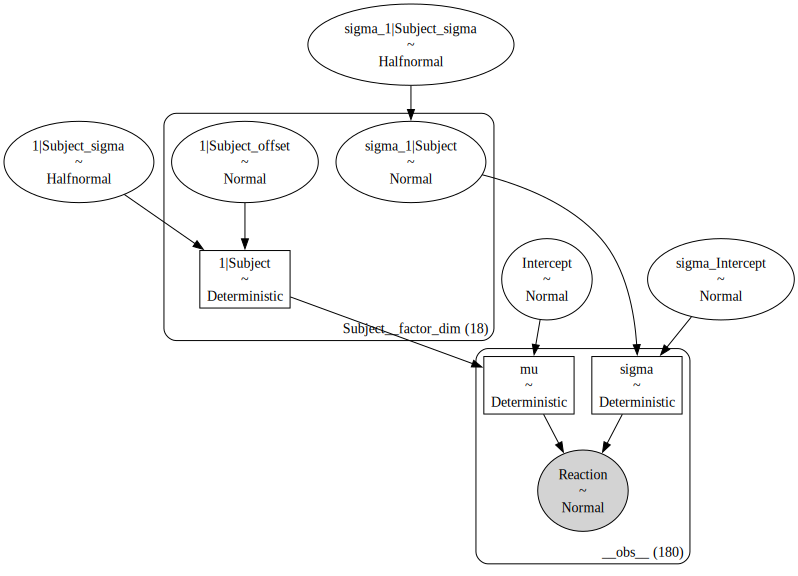

In [6]:
formula = bmb.Formula(
    "Reaction ~ 1 + (1 | Subject)",
    "sigma ~ 1 + (1 | Subject)",
)

# Per-prior `noncentered=` is set independently on each component's prior.
parent_prior = bmb.Prior(
    "Normal",
    mu=0,
    sigma=bmb.Prior("HalfNormal", sigma=1),
    noncentered=True,   # parent component (mu): non-centered
)
sigma_prior = bmb.Prior(
    "Normal",
    mu=0,
    sigma=bmb.Prior("HalfNormal", sigma=1),
    noncentered=False,  # auxiliary component (sigma): centered
)

priors = {
    "1|Subject": parent_prior,                  # parent (mu) component
    "sigma": {"1|Subject": sigma_prior},        # auxiliary component
}

m_dist = bmb.Model(formula, data, priors=priors)
m_dist.build()
m_dist.graph()


## Setting `noncentered` per component

When every group-specific term in the same component should share the same parameterization, the per-prior form gets repetitive. `Model.noncentered` therefore also accepts a `dict` keyed by component name, like `{"mu": True, "sigma": False}` for a Gaussian.

Missing keys default to `True`. Per-prior overrides still win over the dict entry. Unknown keys raise at model construction with a list of the valid component names.

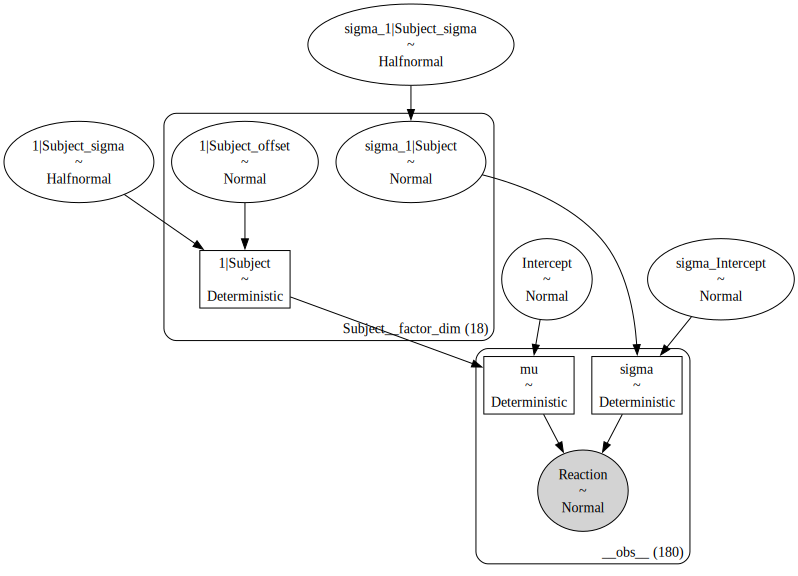

In [7]:
m_dict = bmb.Model(
    formula,
    data,
    noncentered={"mu": True, "sigma": False},  # mu: non-centered, sigma: centered
)
m_dict.build()
m_dict.graph()

## Centered parameterization for non-Normal priors

Non-centered parameterization is only defined for Normal priors with a random `sigma` hyperprior. For any other prior we have to use the centered parameterization. Setting `noncentered=False` on the prior makes this explicit, and the model builds cleanly.

Asking for `noncentered=True` on a non-Normal prior raises a `NotImplementedError` that names the offending prior and points at `noncentered=False` as the fix.

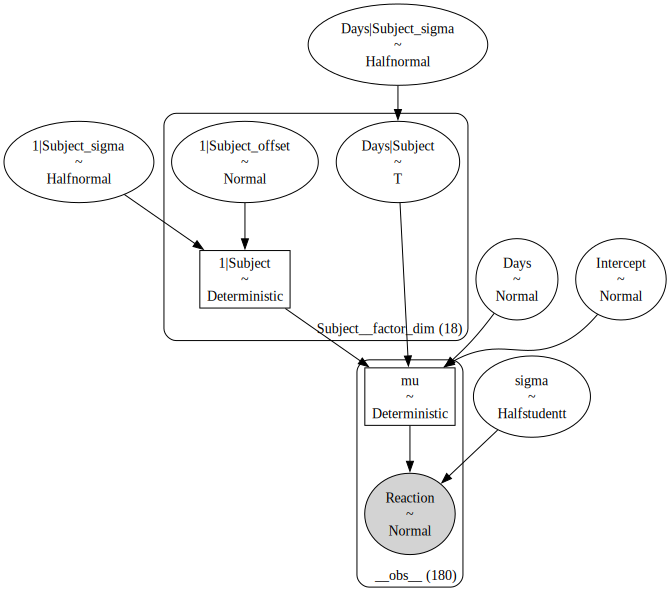

In [8]:
st_prior = bmb.Prior(
    "StudentT",
    nu=4,
    mu=0,
    sigma=bmb.Prior("HalfNormal", sigma=1),
    noncentered=False,
)

m_st = bmb.Model(
    "Reaction ~ Days + (Days | Subject)",
    data,
    priors={"Days|Subject": st_prior},
)
m_st.build()  # used to raise NotImplementedError; now builds via the centered branch
m_st.graph()

## Comparing the two parameterizations

The two parameterizations describe the same probabilistic model. The posterior is the same in expectation; only the sampler's geometry differs. Below we fit the same distributional model twice on the same data and seed, once with both components non-centered, once with both centered.

In [9]:
import arviz as az

# Distributional formula: a regression for *both* mu (the response) and sigma.
# Each component then has its own group-specific intercept by Subject.
dist_formula = bmb.Formula(
    "Reaction ~ Days + (Days | Subject)",
    "sigma ~ 1 + (1 | Subject)",
)

FIT_KW = dict(chains=4, random_seed=1234, progressbar=False)

# Non-centered for both components.
m_nc_fit = bmb.Model(dist_formula, data, noncentered={"mu": True, "sigma": True})
idata_nc = m_nc_fit.fit(**FIT_KW)

# Centered for both components.
m_c_fit = bmb.Model(dist_formula, data, noncentered={"mu": False, "sigma": False})
idata_c = m_c_fit.fit(**FIT_KW)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, Days, 1|Subject_sigma, 1|Subject_offset, Days|Subject_sigma, Days|Subject_offset, sigma_Intercept, sigma_1|Subject_sigma, sigma_1|Subject_offset]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, Days, 1|Subject_sigma, 1|Subject, Days|Subject_sigma, Days|Subject, sigma_Intercept, sigma_1|Subject_sigma, sigma_1|Subject]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [10]:
# Sanity-check that each fit actually picked up the parameterization we asked for.
nc_offsets = sorted(v for v in m_nc_fit.backend.model.named_vars if v.endswith("_offset"))
c_offsets = sorted(v for v in m_c_fit.backend.model.named_vars if v.endswith("_offset"))
print("non-centered offsets:", nc_offsets)
print("centered     offsets:", c_offsets)

div_nc = int(idata_nc.sample_stats["diverging"].sum().item())
div_c = int(idata_c.sample_stats["diverging"].sum().item())
print(f"\ndivergences: non-centered={div_nc}, centered={div_c}")

print("\n--- Population coefficients (mu component) ---")
print("non-centered:")
print(az.summary(idata_nc, var_names=["Intercept", "Days"], kind="stats", round_to=2))
print("\ncentered:")
print(az.summary(idata_c, var_names=["Intercept", "Days"], kind="stats", round_to=2))

non-centered offsets: ['1|Subject_offset', 'Days|Subject_offset', 'sigma_1|Subject_offset']
centered     offsets: []

divergences: non-centered=1, centered=0

--- Population coefficients (mu component) ---
non-centered:
             mean    sd  eti89_lb  eti89_ub
Intercept  251.67  7.80     239.8    264.39
Days        10.35  1.67       7.7     13.02

centered:
             mean    sd  eti89_lb  eti89_ub
Intercept  251.83  7.84    239.62    264.14
Days        10.29  1.63      7.73     12.88


The offset lists confirm that the two fits use the parameterizations we asked for. Posterior means and credible intervals for `Intercept` and `Days` agree between the two fits; the divergence count is parameterization-dependent and is one of the diagnostics that motivates choosing one form over the other for a given dataset.